# 02 · Exploratory Data Analysis (SQL-driven)

DuckDB SQL over the training partition. We look for the signals a fraud model can exploit: time-of-day patterns, amount behaviour by class, and which features separate fraud from legitimate transactions.

In [1]:
# --- project-root bootstrap: portable across VS Code / Jupyter / CLI ---
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / 'config' / 'config.yaml').exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
print('working dir:', Path.cwd())

working dir: /Users/asfalanoi/app_2026/fraud_detection


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from fraud.io import query, read_parquet

train = read_parquet('data/processed/train.parquet')
train.shape

(227845, 31)

In [3]:
# Fraud rate by hour of day
hourly = query(
    'SELECT CAST((Time/3600) % 24 AS INTEGER) AS hour, COUNT(*) AS n, '
    'SUM(Class) AS frauds, ROUND(100.0*SUM(Class)/COUNT(*),4) AS fraud_pct '
    'FROM t GROUP BY hour ORDER BY hour', t=train)
hourly

,hour,n,frauds,fraud_pct
0,0,3696,2.0,0.0541
1,1,4554,7.0,0.1537
2,2,2513,45.0,1.7907
3,3,3314,11.0,0.3319
4,4,2001,16.0,0.7996
5,5,1691,14.0,0.8279
6,6,2737,9.0,0.3288
7,7,4334,9.0,0.2077
8,8,6865,15.0,0.2185
9,9,10750,5.0,0.0465


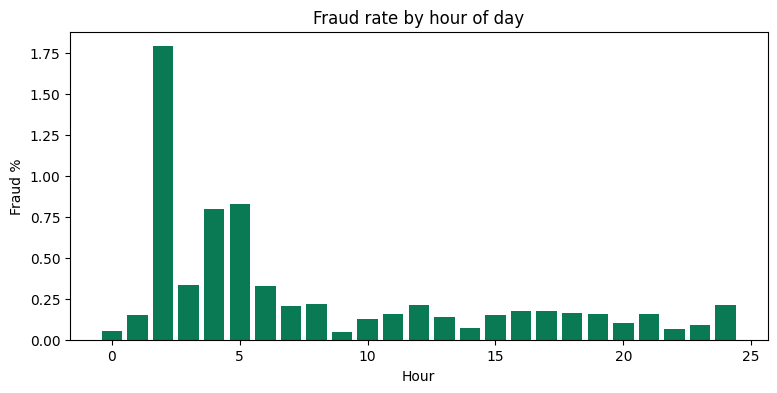

In [4]:
import os
os.makedirs('reports/figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hourly['hour'], hourly['fraud_pct'], color='#0a7a55')
ax.set(title='Fraud rate by hour of day', xlabel='Hour', ylabel='Fraud %')
fig.savefig('reports/figures/fraud_rate_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

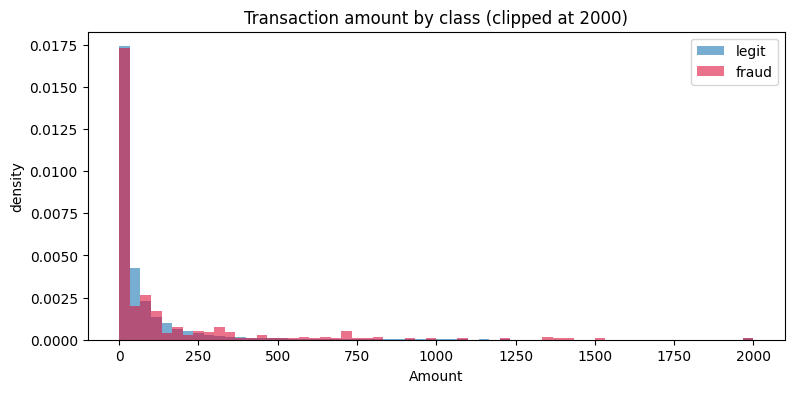

In [5]:
# Amount distribution: legit vs fraud (clipped for readability)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train.loc[train.Class == 0, 'Amount'].clip(upper=2000), bins=60,
        alpha=.6, density=True, label='legit')
ax.hist(train.loc[train.Class == 1, 'Amount'].clip(upper=2000), bins=60,
        alpha=.6, density=True, label='fraud', color='crimson')
ax.set(title='Transaction amount by class (clipped at 2000)',
       xlabel='Amount', ylabel='density')
ax.legend()
fig.savefig('reports/figures/amount_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# Which features separate fraud best?
corr = train.corr(numeric_only=True)['Class'].drop('Class')
corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)

V17   -0.321937
V14   -0.301054
V12   -0.259989
V10   -0.217894
V3    -0.194135
V16   -0.193826
V7    -0.186184
V11    0.153709
V4     0.135014
V18   -0.108732
Name: Class, dtype: float64

**Read:** fraud concentrates in specific hours and skews to smaller amounts; a handful of PCA features carry most of the separating signal. **Next:** `03_data_quality`.